## Comparative Analysis of Champion Configurations
- Input:
    - angumented datasets
    - Exploration data of marginalized BO
    - Exploration data of Random Search
- Pass the optimal hyperparameter configurations from HB, RS, and MBO into the model, train them fully, and then compare the test accuracy. All parameters are kept consistent to ensure a fair comparison.

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import time
import shutil
import pathlib
import itertools
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import models, optimizers, metrics, layers, regularizers, losses
from keras.models import Sequential
from keras.optimizers import SGD, RMSprop, Adam, Adagrad
import json

def set_reproducibility(seed=88):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
    print(f"✅ 全局随机种子已设置为: {seed}，并已启用TensorFlow确定性操作。")

SEED_VALUE = 88 
set_reproducibility(SEED_VALUE)

2025-09-24 12:02:20.687028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758715340.894875      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758715340.955436      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ 全局随机种子已设置为: 88，并已启用TensorFlow确定性操作。


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.image as img

!pip install split-folders -q
import splitfolders
input_dir="/kaggle/input/augmented-alzheimer-data/augmented_data"
output_dir="./output"
splitfolders.ratio(
    input_dir, 
    output=output_dir, 
    seed=1345, 
    ratio=(.70, 0.15,0.15),
    group_prefix=None 
) 
print("Dataset split completed!")

#验证输出路径文件夹文件数量
def count_files(directory):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(directory, split)
        print(f"\n{split.upper()} set:")
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            num_files = len(os.listdir(class_path))
            print(f"  {class_name}: {num_files} images")

count_files("./output")

AUTOTUNE = tf.data.AUTOTUNE
IMG_HEIGHT = 224
IMG_WIDTH = 224 
batch_size=32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/train",
seed=123,
label_mode='int',
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=True
).prefetch(buffer_size=AUTOTUNE)
# 默认情况下label_mode='int'后续匹配sparse_categorical_crossentropy	需设置from_logits=True/False


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/test",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False  
).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
"./output/val",
label_mode='int',
seed=123,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=batch_size,
shuffle=False
).prefetch(buffer_size=AUTOTUNE)

Copying files: 12800 files [00:53, 239.03 files/s]


Dataset split completed!

TRAIN set:
  MildDemented: 2240 images
  NonDemented: 2240 images
  VeryMildDemented: 2240 images
  ModerateDemented: 2240 images

VAL set:
  MildDemented: 480 images
  NonDemented: 480 images
  VeryMildDemented: 480 images
  ModerateDemented: 480 images

TEST set:
  MildDemented: 480 images
  NonDemented: 480 images
  VeryMildDemented: 480 images
  ModerateDemented: 480 images
Found 8960 files belonging to 4 classes.


I0000 00:00:1758715415.607141      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758715415.607806      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1920 files belonging to 4 classes.
Found 1920 files belonging to 4 classes.


In [ ]:
import os, random, time, gc, json
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import tensorflow as tf, tensorflow_probability as tfp
from tensorflow import keras
from keras import layers, regularizers
import scipy.stats as stats
tfd = tfp.distributions
sns.set_style('whitegrid')
tf.keras.backend.set_floatx('float64')

#-----------------------------模型架构搭建：顺序模型------------------------------
def build_pretrained_model(hparams):
    
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    
    base_model.trainable = False
    
    fine_tune_at_block = 'block5a_expand_conv'
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == fine_tune_at_block:
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    
    dense_units = int(hparams.get('dense_units', 128))
    dropout_rate = hparams.get('dropout_rate', 0.5)
    l2_reg = hparams.get('l2_reg', 0.001)
    lr = hparams.get('lr', 0.0001)
    optimizer_choice = int(hparams.get('optimizer_choice', 0))
    momentum = hparams.get('momentum', 0.9)
    
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), 
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)), 
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax') 
    ])

    if optimizer_choice == 0:
        print("--- 使用 Adam 优化器 ---")
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == 1:
        print(f"--- 使用 SGD 优化器 (momentum={momentum:.3f}) ---")
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    elif optimizer_choice == 2:
        print("--- 使用 RMSprop 优化器 ---")
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else: # optimizer_choice == 3
        print("--- 使用 Adagrad 优化器 ---")
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
   
    return model

class TrainingCallback(keras.callbacks.Callback):
    def __init__(self, epochs):
        super().__init__()
        self.epochs = epochs
    def on_train_begin(self, logs=None):
        header = "{0:^8s}{1:^11s}{2:^11s}{3:^12s}{4:^12s}{5:^12s}".format('Epoch', 'Loss', 'Acc', 'Val_Loss', 'Val_Acc', 'Duration')
        print(header)
    def on_epoch_begin(self, epoch, logs=None): 
        self.ep_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.ep_start
        acc = logs.get('accuracy', 0); val_acc = logs.get('val_accuracy', 0)
        loss = logs.get('loss', 0); val_loss = logs.get('val_loss', 0)
        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^10.3f}{acc * 100:^11.3f}{val_loss:^12.5f}{val_acc * 100:^12.3f}{duration:^12.2f}'
        print(msg)
        

def train_and_evaluate_model(hparams,train_ds,val_ds,epochs=30):
    #创建模型
    model = build_pretrained_model(hparams) 
    
    training_callback = TrainingCallback(
        epochs=epochs
    )
    
    early_stopping_callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,  # 验证集准确率连续5个epoch没有提升就停止
        min_delta=0.005,
        restore_best_weights=True, # 自动恢复到性能最好的那个epoch的权重
        verbose=0 
    )
    
    #训练模型
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=0,
        callbacks=[training_callback,early_stopping_callback]
    )

    loss, accuracy = model.evaluate(val_ds, verbose=0)
    best_epoch_num = early_stopping_callback.best_epoch + 1
    print(f"  > 训练评估完成: Best Val Acc: {accuracy:.4f}, 对应的 Loss:{loss:.4f}(at epoch {best_epoch_num})")
    
    return accuracy


import gc 

def my_objective_fn(x_new):
    # 将优化器给出的numpy数组转换为超参数字典
    hparams = {
        'lr': x_new[0],
        'dense_units': int(x_new[1]),
        'dropout_rate': x_new[2],
        'l2_reg': x_new[3],
        'optimizer_choice': int(x_new[4]),
        'momentum': x_new[5],
    }
    # 清理会话并调用训练函数
    tf.keras.backend.clear_session()
    gc.collect()
    print(f"\n正在评估超参数: {hparams}")
    accuracy = train_and_evaluate_model(hparams, train_ds, val_ds, epochs=12)
    print(f"评估完成 - 验证集准确率: {accuracy:.4f}")
    return accuracy

✅ Log file '/kaggle/input/random-data-25/second_resumed_random_search_25.json' loaded successfully! Loaded 25 evaluation records.

--- 随机搜索找到的最佳参数组合 ---
  - lr: 0.0003
  - dense_units: 291
  - dropout_rate: 0.4642
  - l2_reg: 0.0045
  - optimizer_choice: 2
  - momentum: 0.9500
全局随机探索最优Val Accuracy:0.9750 at point 1
✅ Log file '/kaggle/input/bo-data-30/second_continued_EI_MCMC_BO_log30.json' loaded successfully! Loaded 30 evaluation records.

--- 贝叶斯优化找到的最佳参数组合 ---
  - lr: 0.0001
  - dense_units: 398
  - dropout_rate: 0.2890
  - l2_reg: 0.0009
  - optimizer_choice: 2
  - momentum: 0.9275
BO阶段最优Val Accuracy:0.9844 at point 23
- Absolute Improvement from Bayesian Opt: +0.0094 points
- Relative Improvement from Bayesian Opt: +0.96%


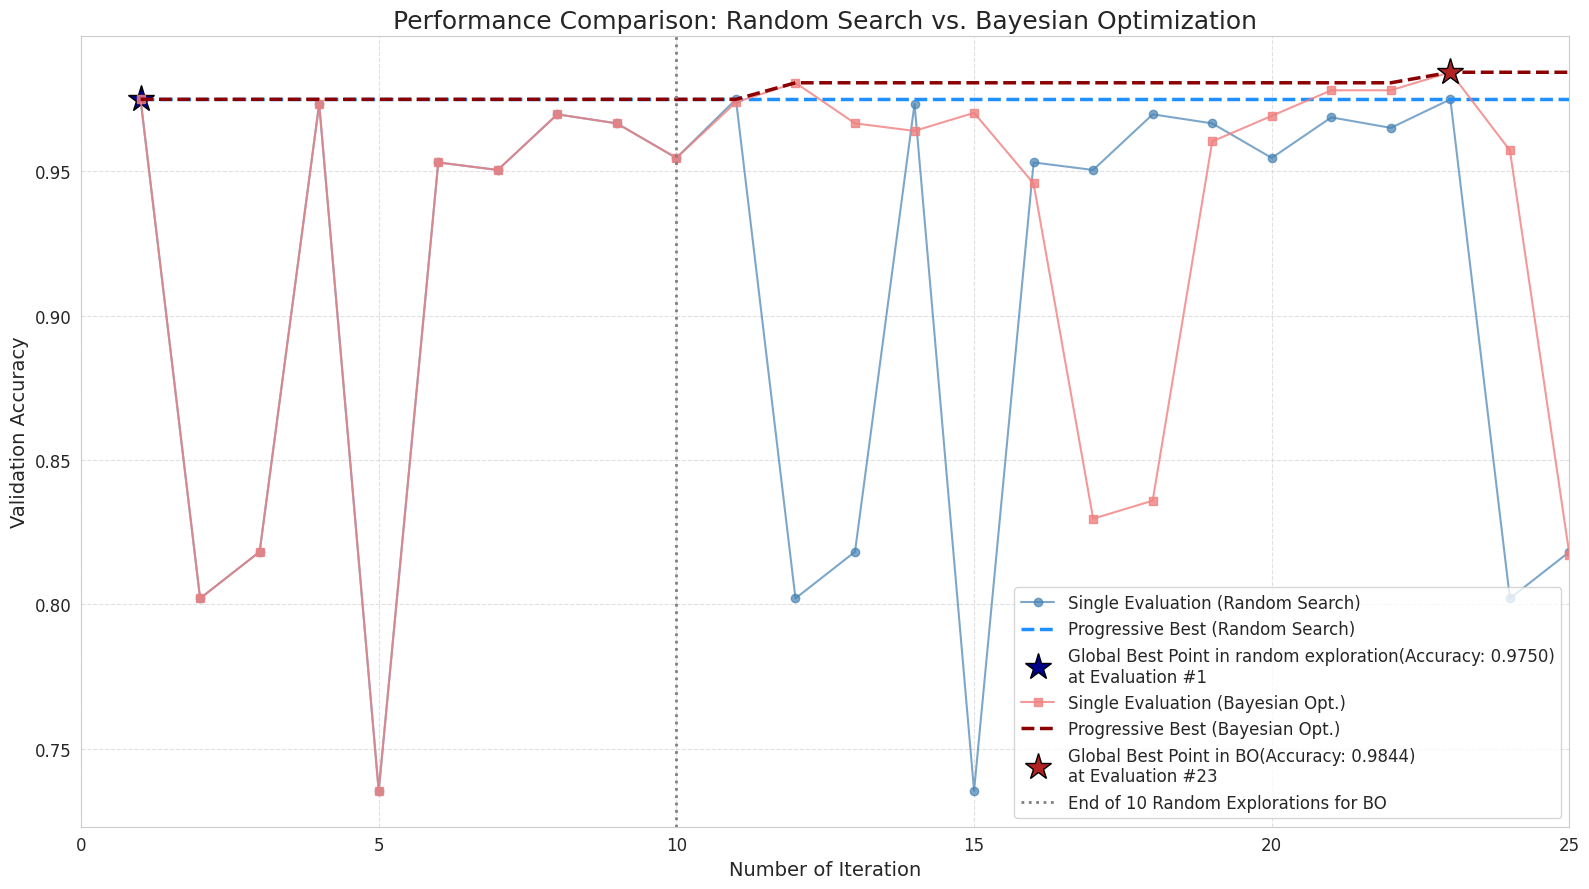

In [ ]:
# ===================================================================
# 贝叶斯优化全过程的图像表示(从导入贝叶斯迭代数据开始)
# ===================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
initial_points_bo=10

log_file_random = "/kaggle/input/random-data-25/second_resumed_random_search_25.json" 
log_file_BO="/kaggle/input/bo-data-30/second_continued_EI_MCMC_BO_log30.json" 

def load_accuracies_from_log(file_path):
    try:
        with open(file_path, 'r') as f:
            logs = [json.loads(line) for line in f if line.strip()]
        accuracies = [log['accuracy'] for log in logs]
        best_log_entry=max(logs,key=lambda entry:entry['accuracy'])
        best_params=best_log_entry['params']
        print(f"✅ Log file '{file_path}' loaded successfully! Loaded {len(accuracies)} evaluation records.")
        return accuracies, best_params
        
    except FileNotFoundError:
        print(f"❌ 错误: 日志文件 '{file_path}' 未找到。请检查路径。")
        return None
    except Exception as e:
        print(f"处理文件 '{file_path}' 时出错: {e}")
        return None

accuracies_random, best_params_random = load_accuracies_from_log(log_file_random)
best_idx_random = np.argmax(accuracies_random)
best_x_random = best_idx_random + 1
best_y_random = accuracies_random[best_idx_random]
# 打印随机搜索找到的最佳参数
if best_params_random:
    print("\n--- 随机搜索找到的最佳参数组合 ---")
    for key, value in best_params_random.items():
        if key in ['dense_units', 'optimizer_choice']:
            print(f"  - {key}: {int(value)}")
        else:
            print(f"  - {key}: {value:.4f}")
    print(f"全局随机探索最优Val Accuracy:{best_y_random:.4f} at point {best_x_random}")

accuracies_bo, best_params_bo = load_accuracies_from_log(log_file_BO)
best_idx_bo = np.argmax(accuracies_bo)
best_x_bo=best_idx_bo+1
best_y_bo=accuracies_bo[best_idx_bo]
# 打印贝叶斯优化找到的最佳参数
if best_params_bo:
    if best_idx_bo>initial_points_bo:
        print("\n--- 贝叶斯优化找到的最佳参数组合 ---")
        for key, value in best_params_bo.items():
            if key in ['dense_units', 'optimizer_choice']:
                print(f"  - {key}: {int(value)}")
            else:
                print(f"  - {key}: {value:.4f}")
        print(f"BO阶段最优Val Accuracy:{best_y_bo:.4f} at point {best_x_bo}")
        absolute_improvement=max(0, best_y_bo-best_y_random)
        if best_y_random > 0:
            relative_improvement = (absolute_improvement / best_y_random) * 100
            print(f"- Absolute Improvement from Bayesian Opt: +{absolute_improvement:.4f} points")
            print(f"- Relative Improvement from Bayesian Opt: +{relative_improvement:.2f}%")
        else:
            print(f"- Absolute Improvement from Bayesian Opt: +{absolute_improvement:.4f} points")
        print("="*50)
        
    else: 
        print("警告：BO 没有找到更好的超参数点！")

#===========================================================================================
# 画图部分
#===========================================================================================
if accuracies_random is not None and accuracies_bo is not None:
    plt.figure(figsize=(16,9))
    # 绘制纯随机搜索的数据 
    n_evals_random = len(accuracies_random)
    x_axis_random = np.arange(1, n_evals_random + 1)
    # 绘制每次评估的准确率
    plt.plot(x_axis_random, accuracies_random, 'o-', color='steelblue', 
             alpha=0.7, label='Single Evaluation (Random Search)')
    # 绘制累积最佳准确率曲线
    plt.plot(x_axis_random, np.maximum.accumulate(accuracies_random),linestyle='--', 
             color='dodgerblue', linewidth=2.5, 
             label='Progressive Best (Random Search)')
    plt.plot(best_x_random, best_y_random, 
             marker='*', 
             color='darkblue', 
             markersize=20, 
             markeredgecolor='black',
             linestyle='', 
             label=f'Global Best Point in random exploration(Accuracy: {best_y_random:.4f})\nat Evaluation #{best_x_random}')

    n_evals_bo = len(accuracies_bo)
    x_axis_bo = np.arange(1, n_evals_bo + 1)
    
    plt.plot(x_axis_bo, accuracies_bo, 's-', color='lightcoral', 
             alpha=0.8, label='Single Evaluation (Bayesian Opt.)')
    plt.plot(x_axis_bo, np.maximum.accumulate(accuracies_bo),linestyle='--', 
             color='darkred', linewidth=2.5, 
             label='Progressive Best (Bayesian Opt.)')
    plt.plot(best_x_bo, best_y_bo, 
             marker='*', 
             color='firebrick', #最深的红色
             markersize=20, 
             markeredgecolor='black',
             linestyle='', 
             label=f'Global Best Point in BO(Accuracy: {best_y_bo:.4f})\nat Evaluation #{best_x_bo}')
    
    # 在BO曲线上标记随机探索结束的位置
    if n_evals_bo > initial_points_bo:
        plt.axvline(initial_points_bo, color='gray', linestyle=':', linewidth=2, 
                    label=f'End of {initial_points_bo} Random Explorations for BO')

    plt.title('Performance Comparison: Random Search vs. Bayesian Optimization', fontsize=18)
    plt.xlabel('Number of Iteration', fontsize=14)
    plt.ylabel('Validation Accuracy', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlim(0, 25)
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.tight_layout()

    # 保存并显示图像
    plt.savefig('comparison_random_vs_bo22.png')
    plt.show()

else:
    print("\n未能成功加载所有日志文件，无法生成比较图。")

--- 发现以下冠军超参数进行对决 ---

🏆 Human Baseline:
   - lr: 0.000050
   - dense_units: 256
   - dropout_rate: 0.500000
   - l2_reg: 0.001000
   - optimizer_choice: 0
   - momentum: 0.900000

🏆 Random Search Champion:
   - lr: 0.000327
   - dense_units: 291
   - dropout_rate: 0.464171
   - l2_reg: 0.004482
   - optimizer_choice: 2
   - momentum: 0.950002

🏆 BO Champion:
   - lr: 0.000103
   - dense_units: 398
   - dropout_rate: 0.289009
   - l2_reg: 0.000877
   - optimizer_choice: 2
   - momentum: 0.927550

🥊 开始最终训练: Human Baseline
✅ 全局随机种子已设置为: 88，并已启用TensorFlow确定性操作。
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- 使用 Adam 优化器 ---
 Epoch     Loss        Acc      Val_Loss    Val_Acc     Duration  


E0000 00:00:1758715448.285597      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1758715450.747005      73 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1 /100    1.239     62.243     0.95921      74.271      184.17   
 2 /100    0.936     75.033     0.83439      80.052      155.86   
 3 /100    0.838     79.342     0.76775      81.979      155.80   
 4 /100    0.748     82.701     0.70955      83.854      155.84   
 5 /100    0.659     86.417     0.61733      88.438      155.78   
 6 /100    0.592     88.873     0.56464      90.573      155.62   
 7 /100    0.512     91.618     0.55346      90.938      155.78   
 8 /100    0.461     93.170     0.47293      93.177      155.66   
 9 /100    0.408     94.866     0.40059      95.156      155.72   
10 /100    0.379     95.592     0.44919      94.219      155.74   
11 /100    0.342     96.596     0.37203      95.573      155.77   
12 /100    0.310     97.567     0.35364      95.938      155.80   
13 /100    0.300     97.254     0.33253      96.042      155.77   
14 /100    0.277     97.801     0.30679      96.562      155.84   
15 /100    0.260     98.036     0.32941      96.250      155.7

E0000 00:00:1758721271.226274      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /100    2.064     61.462     1.04298      76.979      176.51   
 2 /100    0.817     77.221     0.75893      74.635      153.64   
 3 /100    0.501     82.935     0.41224      84.531      153.66   
 4 /100    0.347     88.170     0.25475      92.031      153.60   
 5 /100    0.241     92.020     0.25308      91.406      153.72   
 6 /100    0.175     94.967     0.46297      86.875      153.58   
 7 /100    0.138     96.016     0.28516      90.729      153.66   
 8 /100    0.112     96.808     0.15724      95.729      153.61   
 9 /100    0.098     97.489     0.18289      94.479      153.58   
10 /100    0.086     97.723     0.22045      94.062      153.57   
11 /100    0.071     98.270     0.32829      93.229      153.55   

Epoch 11: ReduceLROnPlateau reducing learning rate to 6.54600028365963e-05.
12 /100    0.026     99.554     0.08169      97.812      153.56   
13 /100    0.014     99.743     0.08676      98.125      153.51   
14 /100    0.010     99.833     0.10015      97.865 

E0000 00:00:1758725633.758211      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /100    1.263     64.230     1.12755      72.031      174.82   
 2 /100    0.953     77.757     0.96429      75.104      153.46   
 3 /100    0.802     81.987     0.84741      79.010      153.53   
 4 /100    0.675     86.451     0.60780      89.323      153.53   
 5 /100    0.556     90.112     0.54690      89.479      153.55   
 6 /100    0.464     93.069     0.51436      90.521      153.74   
 7 /100    0.383     95.123     0.37509      95.156      153.66   
 8 /100    0.322     96.484     0.45183      92.344      153.72   
 9 /100    0.278     97.109     0.29997      96.146      153.93   
10 /100    0.238     97.656     0.31936      95.260      153.73   
11 /100    0.206     97.924     0.32652      94.062      153.64   
12 /100    0.178     98.382     0.22519      96.458      153.93   
13 /100    0.155     98.616     0.20638      97.083      153.65   
14 /100    0.137     98.661     0.19924      97.500      153.61   
15 /100    0.125     98.705     0.19690      96.562      153.6

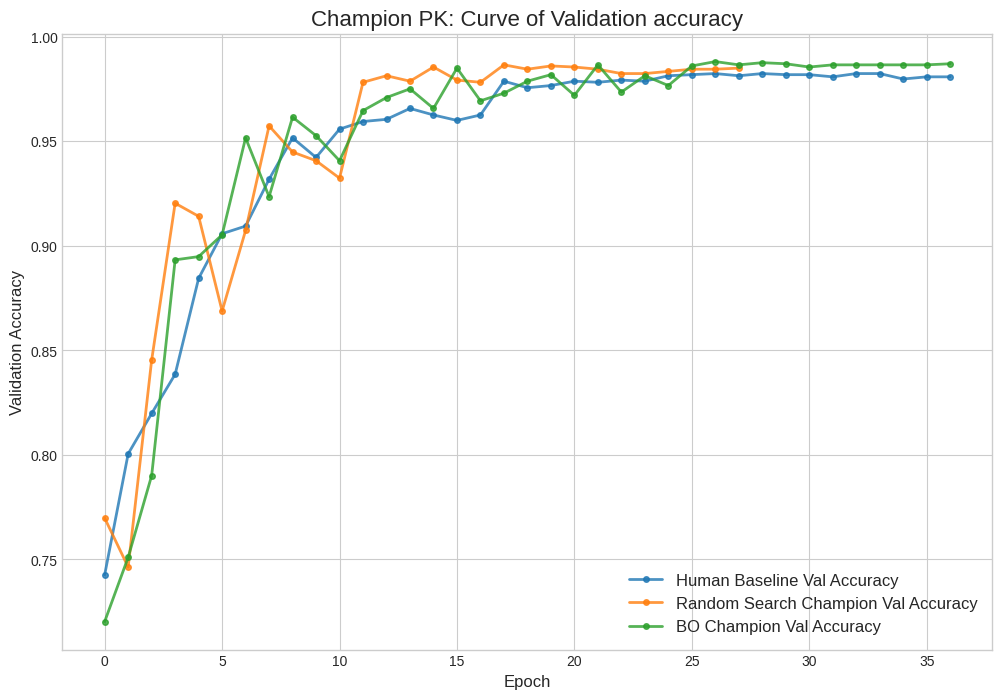

In [ ]:
# ===================================================================
# 单元格: 冠军对决 (Champion Showdown)
# ===================================================================
import json
import pandas as pd
import matplotlib.pyplot as plt
import gc
import time
import numpy as np

# ===================================================================
# 定义用于加载和找出三组冠军超参数的函数
# ===================================================================
def get_champion_hyperparameters(log_file_random, log_file_bo, init_points_bo=5):
    """
    从两个日志文件中加载结果，并找出三组冠军超参数。
    """
    
    def load_full_logs(file_path):
        """辅助函数，用于加载完整的日志条目。"""
        try:
            with open(file_path, 'r') as f:
                return [json.loads(line) for line in f if line.strip()]
        except FileNotFoundError:
            print(f"❌ 错误: 日志文件 '{file_path}' 未找到。")
            return None

    # 加载两个日志文件的全部数据
    logs_random = load_full_logs(log_file_random)
    logs_bo = load_full_logs(log_file_bo)

    if not logs_random or not logs_bo:
        print("缺少必要的日志文件，无法继续。")
        return None

    # 找出随机探索冠军
    best_random_entry = max(logs_random, key=lambda log: log['accuracy'])
    random_champion_params = best_random_entry['params']

    # 找出贝叶斯优化阶段的冠军
    # 只在第 `init_points_bo` 个点之后的部分进行搜索
    bo_phase_logs = logs_bo[init_points_bo:]
    if bo_phase_logs:
        best_bo_entry = max(bo_phase_logs, key=lambda log: log['accuracy'])
        bo_champion_params = best_bo_entry['params']
    else:
        print("警告: 贝叶斯优化阶段没有数据点，将跳过此冠军。")
        bo_champion_params = {}

    # 定义人类基准冠军
    manual_baseline_params = {
        'lr': 0.00005,
        'dense_units': 256.0,
        'dropout_rate': 0.5,
        'l2_reg': 0.001,
        'optimizer_choice': 0, # Adam
        'momentum': 0.9      # Adam不直接使用此参数，但为结构统一而保留
    }
    
    champions = {
        "Human Baseline": manual_baseline_params,
        "Random Search Champion": random_champion_params,
        "BO Champion": bo_champion_params,
    }
    
    final_champions = {}
    for name, params in champions.items():
        if params: # 如果参数字典不为空
            if 'dense_units' in params:
                params['dense_units'] = int(params['dense_units'])
            if 'optimizer_choice' in params:
                params['optimizer_choice'] = int(params['optimizer_choice'])
            final_champions[name] = params

    print("--- 发现以下冠军超参数进行对决 ---")
    for name, params in final_champions.items():
        print(f"\n🏆 {name}:")
        for key, value in params.items():
            if isinstance(value, int):
                print(f"   - {key}: {value}")
            else:
                print(f"   - {key}: {float(value):.6f}")
            
    return final_champions

# ===================================================================
# 定义最终的训练与评估函数 
# ===================================================================
def train_and_evaluate_champion(hparams, train_ds, val_ds, test_ds):
    tf.keras.backend.clear_session(); gc.collect()
    
    # 确保传入的hparams中的optimizer_choice是整数
    if 'optimizer_choice' in hparams:
        hparams['optimizer_choice'] = int(hparams['optimizer_choice'])
        
    model = build_pretrained_model(hparams)
    
    # 为最终对决设置更长的训练周期和patience
    MAX_EPOCHS = 100
    PATIENCE = 10

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=PATIENCE, 
        min_delta=0.001, 
        restore_best_weights=True, 
        verbose=1)
    
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
    
    logging_callback = TrainingCallback(epochs=MAX_EPOCHS)
    
    start_time = time.time()
    history = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=MAX_EPOCHS, 
        callbacks=[logging_callback, early_stopping, lr_scheduler], 
        verbose=0)
    training_duration = time.time() - start_time
    
    print("\n--- 正在进行最终评估 ---")
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    best_epoch = early_stopping.best_epoch + 1 if early_stopping.best_epoch >= 0 else len(history.history['loss'])

    # 返回包含测试集性能的结果
    return {
        "val_accuracy": val_acc,
        "test_accuracy": test_acc,
        "best_epoch": best_epoch,
        "history": history.history,
        "training_time": training_duration
    }
    
# ===================================================================
# Main
# ===================================================================
log_file_random = "/kaggle/input/random-data-25/second_resumed_random_search_25.json" 
log_file_bo="/kaggle/input/bo-data-30/second_continued_EI_MCMC_BO_log30.json" 

# 获取三组冠军参数
champions_to_train = get_champion_hyperparameters(
    log_file_random=log_file_random,
    log_file_bo=log_file_bo,
    init_points_bo=10
)

final_results = {}
training_histories = {}
if champions_to_train:
    for name, params in champions_to_train.items():
        print(f"\n{'='*60}\n🥊 开始最终训练: {name}\n{'='*60}")

        # 为每次对决重置随机种子，确保公平比较
        set_reproducibility(seed=SEED_VALUE) 
        
        results = train_and_evaluate_champion(params, train_ds, val_ds, test_ds)
        
        final_results[name] = results
        training_histories[name] = results['history']
        
        print(f"✅ 组合 {name} 训练完成!")
        print(f"   - 收敛于轮次 (Converged at Epoch): {results['best_epoch']}")
        print(f"   - 验证集准确率 (Validation Acc): {results['val_accuracy']:.4f}")
        print(f"   - 最终测试集准确率 (Test Acc): {results['test_accuracy']:.4f}")
        print(f"   - 训练耗时: {results['training_time'] / 60:.2f} 分钟")

# ===================================================================
# 结果可视化
# ===================================================================
def format_time(seconds):
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"

if final_results:
    print(f"\n{'='*60}\n🏆 冠军对决最终结果 🏆\n{'='*60}")
    
    results_df = pd.DataFrame({
        'Champion': list(final_results.keys()),
        'Validation Accuracy': [res['val_accuracy'] for res in final_results.values()],
        'Test Accuracy': [res['test_accuracy'] for res in final_results.values()],
        'Converged at Epoch': [res['best_epoch'] for res in final_results.values()],
        'Training Time': [format_time(res['training_time']) for res in final_results.values()]
    }).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

    print(results_df.to_string())
    
    # 保存结果到CSV
    results_df.to_csv("champion_showdown_final_results.csv", index=False)
    print("\n[INFO] 最终对决结果已保存到 champion_showdown_final_results.csv")

    winner = results_df.iloc[0]
    print(f"\n🎉 总冠军是: {winner['Champion']}, 最终测试集准确率为 {winner['Test Accuracy']:.4f}!")

    # 绘制验证集准确率曲线进行比较
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 8))
    for name, history in training_histories.items():
        plt.plot(history['val_accuracy'], label=f'{name} Val Accuracy', lw=2, marker='o', markersize=4, alpha=0.8)

    plt.title('Champion PK: Curve of Validation accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.savefig('championship_curves.png')
    plt.show()
else:
    print("\n未能确定冠军组合，无法开始对决。")

In [ ]:
# ===================================================================
# 保存详细的训练历史数据为JSON 文件
# ===================================================================

if 'training_histories' in locals() and training_histories:
    history_json_path = 'champion_training_histories.json'
    
    try:
        with open(history_json_path, 'w') as f:
            json.dump(training_histories, f, indent=4)
        
        print(f"\n[INFO] ✅ 全部三组冠军的详细训练历史已成功保存到: {history_json_path}")
        
    except Exception as e:
        print(f"\n[ERROR] ❌ 保存JSON文件时出错: {e}")


[INFO] ✅ 全部三组冠军的详细训练历史已成功保存到: champion_training_histories.json


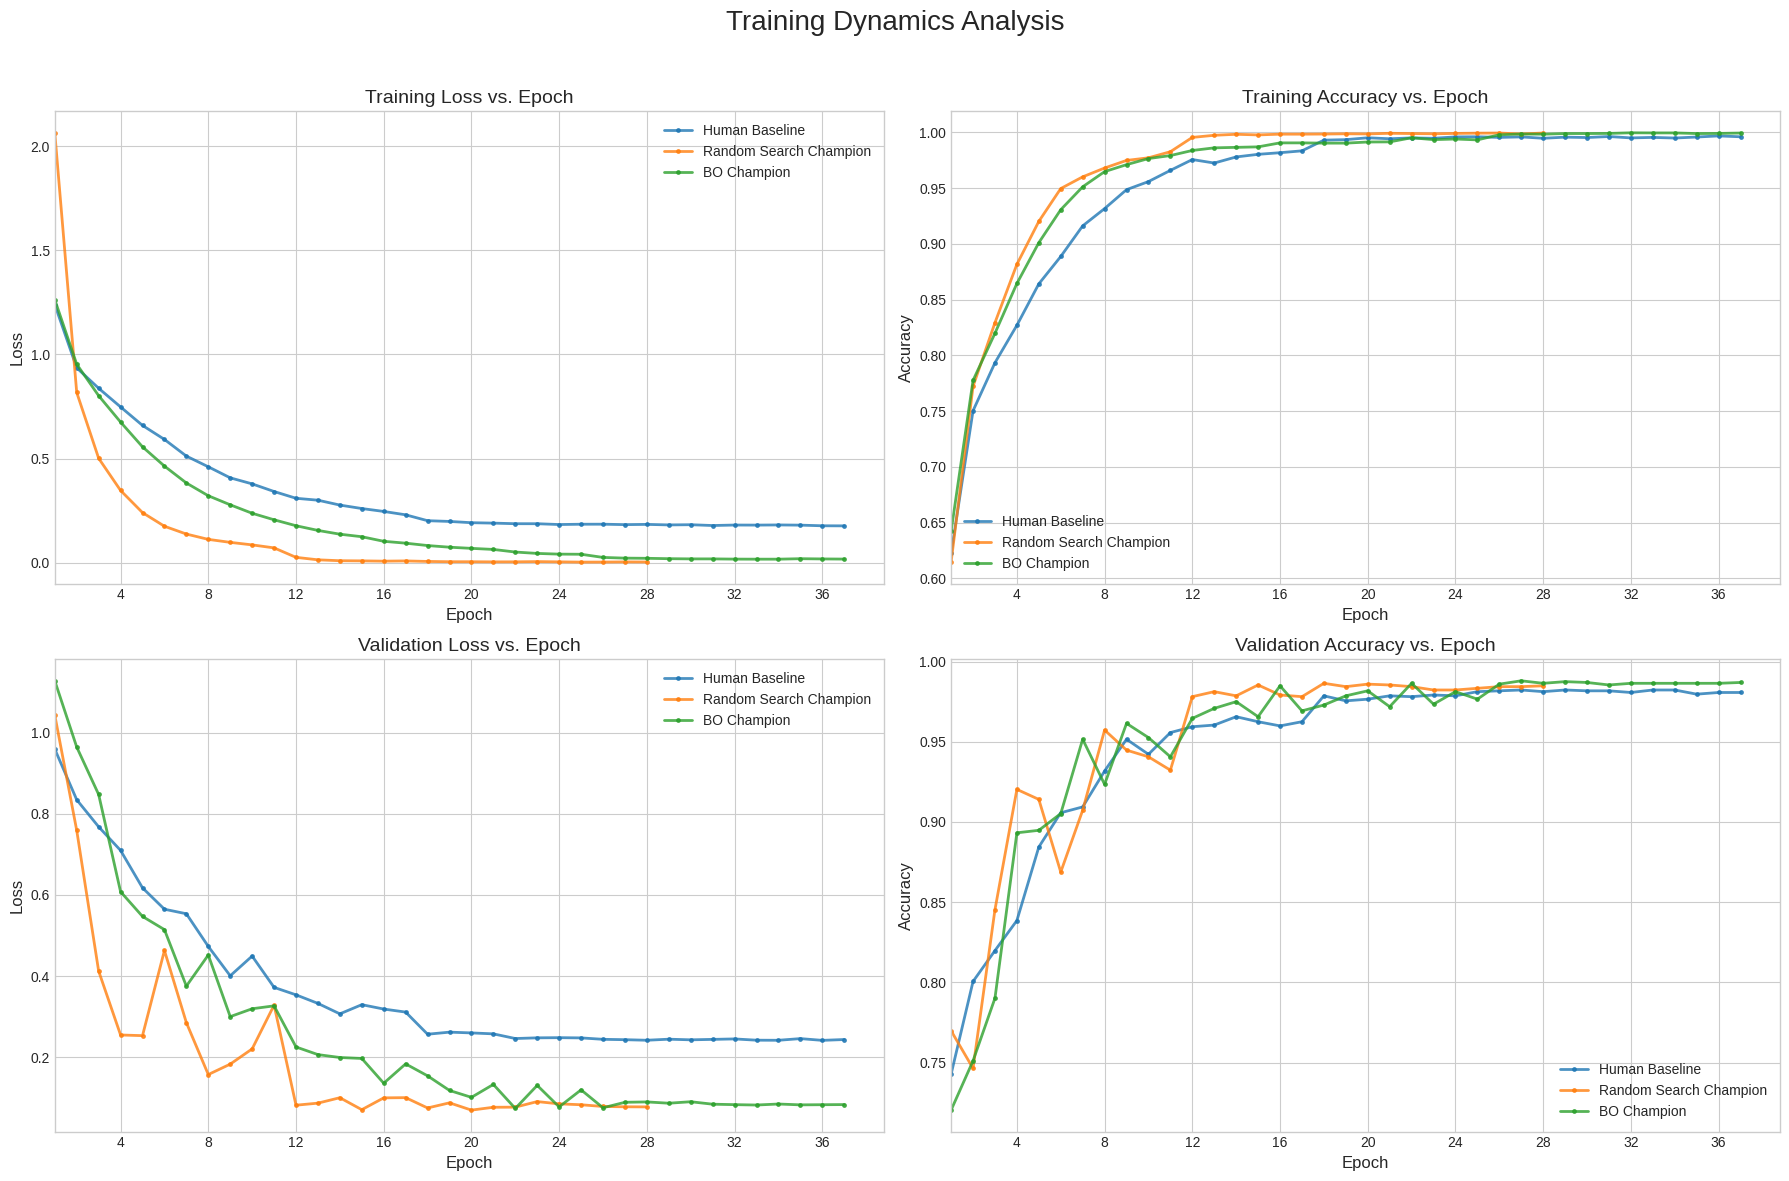

In [ ]:
if final_results:

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
    
    colors = {
        "Human Baseline": "C0", # 蓝色
        "Random Search Champion": "C1", # 橙色
        "BO Champion": "C2"   # 绿色
    }

    # 遍历每个冠军的训练历史
    for name, history in training_histories.items():
        # 提取各个指标的历史数据
        loss_history = history['loss']
        acc_history = history['accuracy']
        val_loss_history = history['val_loss']
        val_acc_history = history['val_accuracy']
        
        # 创建从1开始的Epoch X轴
        epochs = range(1, len(loss_history) + 1)

        # 1. 左上角：训练集损失 (Training Loss)
        axes[0, 0].plot(epochs, loss_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)
        
        # 2. 右上角：训练集准确率 (Training Accuracy)
        axes[0, 1].plot(epochs, acc_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)
        
        # 3. 左下角：验证集损失 (Validation Loss)
        axes[1, 0].plot(epochs, val_loss_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)
        
        # 4. 右下角：验证集准确率 (Validation Accuracy)
        axes[1, 1].plot(epochs, val_acc_history, label=name, color=colors.get(name), lw=2, marker='.', markersize=5, alpha=0.8)

    axes[0, 0].set_title('Training Loss vs. Epoch', fontsize=14)
    axes[0, 1].set_title('Training Accuracy vs. Epoch', fontsize=14)
    axes[1, 0].set_title('Validation Loss vs. Epoch', fontsize=14)
    axes[1, 1].set_title('Validation Accuracy vs. Epoch', fontsize=14)

    for i in range(2):
        for j in range(2):
            axes[i, j].set_xlabel('Epoch', fontsize=12)
            axes[i, j].legend(fontsize=10)
            axes[i, j].grid(True)
            # 确保X轴刻度为整数
            ax = axes[i, j]
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.set_xlim(left=1)

    # 单独设置Y轴标签
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[1, 0].set_ylabel('Loss', fontsize=12)
    axes[1, 1].set_ylabel('Accuracy', fontsize=12)
    
    fig.suptitle('Training Dynamics Analysis', fontsize=20)
    fig.tight_layout(rect=[0, 0, 1, 0.96]) # rect为总标题留出空间

    plt.savefig('championship_match_details_2x2.png')
    plt.show()

else:
    print("\n未能执行最终对决，跳过生成 2x2 曲线图。")